In [257]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
def get_head_angle(df):
        for ind, row in df.iterrows():
            leftear_x = row['ts_leftear_x_cm']
            leftear_y = row['ts_leftear_y_cm']
            rightear_x = row['ts_rightear_x_cm']
            rightear_y = row['ts_rightear_y_cm']
            nose_x = row['ts_nose_x_cm']
            nose_y = row['ts_nose_y_cm']
            angs = []
            if row.odd == 'left':
                for step in range(len(leftear_x)):
                    ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step])*-1)
                    angs.append(ang)
            else:
                for step in range(len(leftear_x)):
                    ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step]))
                    angs.append(ang)

            df.at[ind, 'head_angle'] = gaussian_filter(np.array(np.degrees(angs)),3,mode = 'reflect').astype(object)
def angular_velocity_head(df):
    for ind,row in df.iterrows():
        #filtered_head_angle = gaussian_filter(row.head_angle.astype(float),2)
        df.at[ind,'head_angle_velocity'] = calculate_angular_velocity(row.head_angle.astype(float),60).astype(object)
def angular_velocity_head_corner(df):
    for ind,row in df.iterrows():
        #filtered_head_angle = gaussian_filter(row.head_angle.astype(float),2)
        trace = gaussian_filter(np.array((row.ts_zero_out_angle_to_corner.astype(float))),3,mode = 'reflect').astype(object)
        
        df.at[ind,'head_corner_angle_velocity'] = calculate_angular_velocity(trace.astype(float),60).astype(object)
def distance_at_head_turn(df):
    for ind,row in df.iterrows():
        thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
        df.at[ind,'distance_at_head_turn'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh]

def intial_lateral_error(df):
    for ind,row in df.iterrows():
        if type(row.lateral_error)==float:
            df.at[ind,'intial_lateral_error'] = np.nan
        else:
            df.at[ind,'intial_lateral_error'] = row.lateral_error[0]
         
def avg_lateral_error(df):
    for ind,row in df.iterrows():
        if type(row.lateral_error)==float:
            df.at[ind,'avg_lateral_error'] = np.nan
        else:
            df.at[ind,'avg_lateral_error'] = np.nanmean(row.lateral_error[:int(row.obstacle_ind)])
        
        
def calculate_angular_velocity(angles, frame_rate):
    # Convert angles to radians if they are given in degrees
    angles = np.radians(angles)

    # Calculate angular velocity using NumPy's array operations
    angular_displacements = np.diff(angles)
    angular_velocities = angular_displacements / (1 / frame_rate)
    np.angle(angular_velocities.astype(float))
    return angular_velocities

In [5]:
J704_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J704_training.json",'blank')
J704_train.trial_min_df(training_ses=True)
J704_train_trialpermin_df = J704_train.trialpermin_df

J704_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J704_oadark.json",'blank')
J704_oa.gather_session_df('obstacle',6)
J704_oa_df = J704_oa.df
J704_oa_df = assign_date_index(J704_oa_df)
df_tortuosity(J704_oa_df)
J704_oa.trial_min_df(training_ses=False)
J704_oa_trialpermin_df = J704_oa.trialpermin_df

6


In [20]:


G8CK_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_G8CK_dark_nolight.json",'blank')
G8CK_oa.gather_session_df('obstacle',6)
G8CK_oa_df = G8CK_oa.df
G8CK_oa_df = assign_date_index(G8CK_oa_df)
df_tortuosity(G8CK_oa_df)
G8CK_oa.trial_min_df(training_ses=False)
G8CK_oa_trialpermin_df = G8CK_oa.trialpermin_df

6


In [24]:
distance_calcs(G8CK_oa_df)
deveation(G8CK_oa_df)

In [25]:
J704_oa_df = drop_nans_in_columns(J704_oa_df,'obstacle_ind')
G8CK_oa_df = drop_nans_in_columns(G8CK_oa_df,'obstacle_ind')

In [261]:
dark = pd.concat([J704_oa_df,G8CK_oa_df])
dark = dark.drop(columns=['level_0'])
dark = dark.reset_index()

In [265]:
dark.to_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_oa.h5",'w')

<AxesSubplot: xlabel='date_index', ylabel='time'>

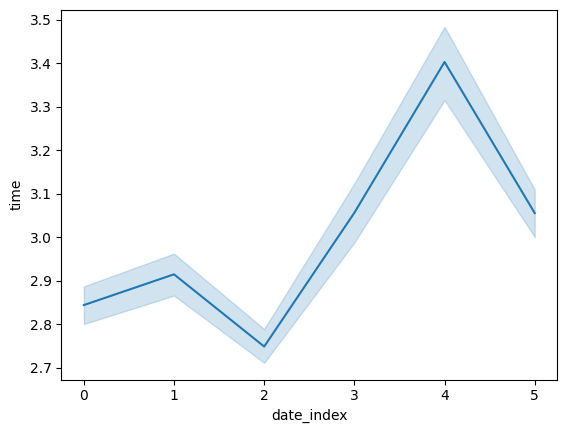

In [76]:
sns.lineplot(data =dark,x = 'date_index', y = 'time' )

<AxesSubplot: xlabel='date_index', ylabel='intial_lateral_error'>

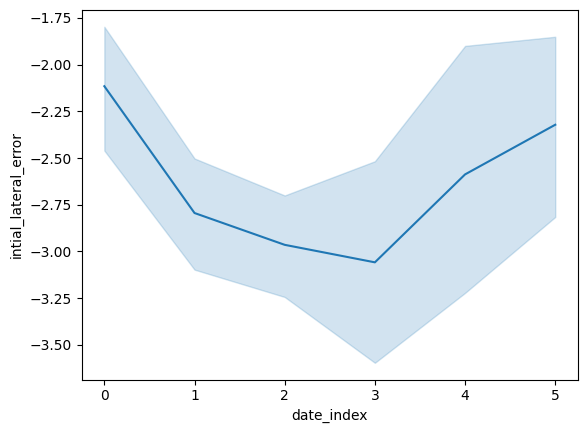

In [263]:
sns.lineplot(data =dark,x = 'date_index', y = 'intial_lateral_error' )

<AxesSubplot: xlabel='date_index', ylabel='avg_lateral_error'>

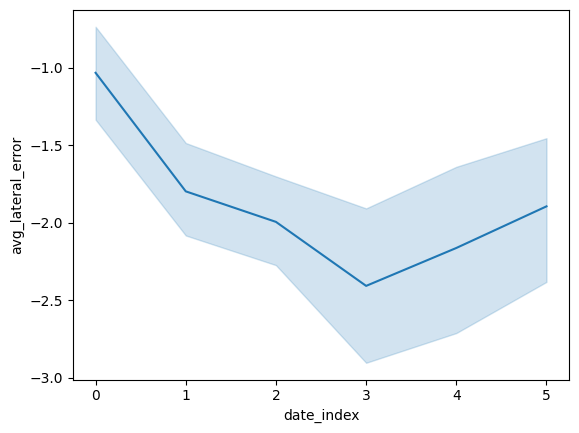

In [262]:
sns.lineplot(data =dark,x = 'date_index', y = 'avg_lateral_error' )

<AxesSubplot: xlabel='date_index', ylabel='linearity'>

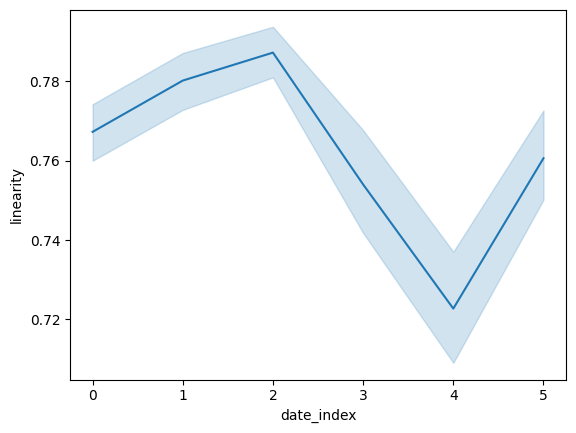

In [75]:
sns.lineplot(data =dark,x = 'date_index', y = 'linearity' )

In [34]:
dark

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,std_interp_ts_nose_y_cm,mad_interp_ts_nose_y_cm,animal_mean_interp_ts_nose_y_cm,animal_median_interp_ts_nose_y_cm,animal_std_interp_ts_nose_y_cm,animal_mad_interp_ts_nose_y_cm,date_mean_interp_ts_nose_y_cm,date_median_interp_ts_nose_y_cm,date_std_interp_ts_nose_y_cm,date_mad_interp_ts_nose_y_cm
0,0,47505.891609,47509.934681,"[47505.898534, 47505.915763, 47505.932262, 475...","[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 8...","[328.7207946777344, 329.1654052734375, 328.590...","[155.78684997558594, 155.62684631347656, 155.2...","[349.27264404296875, 350.23480224609375, 350.8...","[158.1986541748047, 159.5225830078125, 159.554...","[352.93536376953125, 353.16998291015625, 353.2...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,47537.429260,47541.546201,"[47537.442892, 47537.459699, 47537.476275, 475...","[1967, 1968, 1969, 1970, 1971, 1972, 1973, 197...","[83.5278549194336, 83.78058624267578, 83.55388...","[246.58966064453125, 247.1544189453125, 247.15...","[99.87387084960938, 100.0112075805664, 100.174...","[257.7133483886719, 257.5703125, 257.676300048...","[96.67584228515625, 96.56001281738281, 96.9632...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,47541.546201,47545.294348,"[47541.560985, 47541.57815, 47541.594329, 4754...","[[2214, 2215, 2216, 2217, 2218, 2219, 2220, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[660.5409545898438, 660.8740844726562, 660.941...","[243.0141143798828, 242.61697387695312, 241.97...","[667.989990234375, 667.8173217773438, 667.7967...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,47583.095321,47589.104793,"[47583.108633, 47583.125504, 47583.142131, 475...","[[4706, 4707, 4708, 4709, 4710, 4711, 4712, 47...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[662.3052978515625, 663.7036743164062, 663.500...","[240.6185760498047, 239.97161865234375, 240.09...","[666.8388671875, 667.4923095703125, 667.973571...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13,47620.224486,47625.607104,"[47620.238041, 47620.254924, 47620.272076, 476...","[[6933, 6934, 6935, 6936, 6937, 6938, 6939, 69...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[661.7009887695312, 662.1669921875, 662.531982...","[234.65167236328125, 234.87664794921875, 235.2...","[654.8383178710938, 656.1756591796875, 657.398...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875,78,56029.032947,56032.629555,"[56029.040921, 56029.057792, 56029.075737, 560...","[[20991, 20992, 20993, 20994, 20995, 20996, 20...","[673.8978271484375, 674.8469848632812, 674.964...","[262.5647277832031, 262.437255859375, 261.6487...","[663.4574584960938, 664.0390014648438, 664.742...","[247.28787231445312, 247.69454956054688, 247.2...","[662.2060546875, 662.8528442382812, 663.211303...",...,"[3.1812688178971, 3.1129552798950186, 3.077505...","[0.736422293450449, 0.6858157331013572, 0.6137...","[18.828632716547933, 18.54020364446169, 18.266...","[18.855043324080725, 18.526806553365887, 18.20...","[3.1812688178971, 3.1129552798950186, 3.077505...","[0.736422293450449, 0.6858157331013572, 0.6137...","[18.828632716547933, 18.54020364446169, 18.266...","[18.855043324080725, 18.526806553365887, 18.20...","[3.1812688178971, 3.1129552798950186, 3.077505...","[0.736422293450449, 0.6858157331013572, 0.6137..."
2876,82,56099.096768,56101.353740,"[56099.098534, 56099.115302, 56099.131891, 560...","[[25193, 25194, 25195, 25196, 25197, 25198, 25...","[670.5661010742188, 671.2100830078125, 671.647...","[264.86920166015625, 265.5244445800781, 265.91...","[654.9926147460938, 659.0719604492188, 659.795...","[261.98809814453125, 261.3612365722656, 262.20...","[665.630615234375, 666.1615600585938, 666.85

In [40]:
lateral_error(G8CK_oa_df)
heading_calcs(G8CK_oa_df)
get_head_angle(G8CK_oa_df)
angular_velocity_head(G8CK_oa_df)
angular_velocity_head_corner(G8CK_oa_df)
distance_at_head_turn(G8CK_oa_df)
intial_lateral_error(G8CK_oa_df)
avg_lateral_error(G8CK_oa_df)
calculate_speed(G8CK_oa_df)


corner
port


In [62]:
G8CK_oa_df.date_index

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2875    2.0
2876    2.0
2877    2.0
2878    2.0
2879    2.0
Name: date_index, Length: 2880, dtype: float64

In [65]:
dark = pd.concat([J704_oa_df,G8CK_oa_df])

In [66]:
long,short,middle = create_df_by_type(dark)

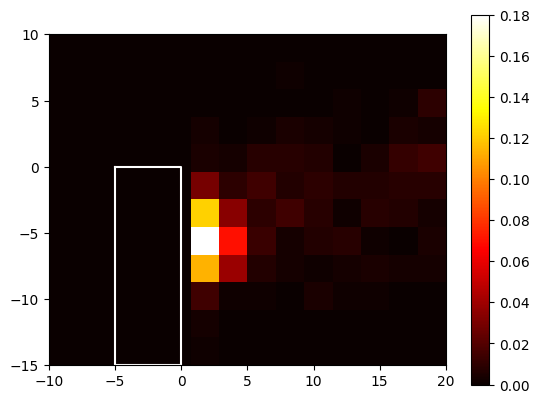

In [82]:
data = pd.concat([long,short])
data = data[(data.date_index == 0)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

In [149]:
from matplotlib.gridspec import GridSpec

In [206]:
(data.animal == 'J701RT') 

3      False
50     False
52     False
78     False
86     False
       ...  
872    False
874    False
886    False
905    False
931    False
Name: animal, Length: 615, dtype: bool

In [217]:
data[(data.animal == 'J704RT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,std_interp_ts_nose_y_cm,mad_interp_ts_nose_y_cm,animal_mean_interp_ts_nose_y_cm,animal_median_interp_ts_nose_y_cm,animal_std_interp_ts_nose_y_cm,animal_mad_interp_ts_nose_y_cm,date_mean_interp_ts_nose_y_cm,date_median_interp_ts_nose_y_cm,date_std_interp_ts_nose_y_cm,date_mad_interp_ts_nose_y_cm
3,9,47583.095321,47589.104793,"[47583.108633, 47583.125504, 47583.142131, 475...","[[4706, 4707, 4708, 4709, 4710, 4711, 4712, 47...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[662.3052978515625, 663.7036743164062, 663.500...","[240.6185760498047, 239.97161865234375, 240.09...","[666.8388671875, 667.4923095703125, 667.973571...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,93,48023.378316,48028.904384,"[48023.394342, 48023.410457, 48023.427264, 480...","[[31114, 31115, 31116, 31117, 31118, 31119, 31...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[659.7802734375, 661.714111328125, 662.9676513...","[241.7122344970703, 242.32852172851562, 242.74...","[664.9398803710938, 666.5917358398438, 667.600...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,95,48031.808947,48036.712000,"[48031.813465, 48031.830246, 48031.847116, 480...","[[31619, 31620, 31621, 31622, 31623, 31624, 31...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[660.3521118164062, 661.8692016601562, 663.276...","[244.16233825683594, 244.1993408203125, 243.76...","[665.9706420898438, 666.5082397460938, 667.140...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,137,48230.849932,48234.151603,"[48230.86624, 48230.882188, 48230.898828, 4823...","[[43558, 43559, 43560, 43561, 43562, 43563, 43...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[664.3280639648438, 664.6197509765625, 664.507...","[234.94679260253906, 235.74346923828125, 236.5...","[660.4207763671875, 660.47314453125, 660.48858...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86,147,48279.371046,48281.599654,"[48279.382195, 48279.398899, 48279.415667, 482...","[[46468, 46469, 46470, 46471, 46472, 46473, 46...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[658.6641845703125, 660.5487060546875, 661.138...","[242.61524963378906, 242.19192504882812, 241.6...","[663.91259765625, 665.365966796875, 665.817626...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,161,48342.565286,48345.477811,"[48342.5707, 48342.587622, 48342.604224, 48342...","[[50258, 50259, 50260, 50261, 50262, 50263, 50...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[663.4468994140625, 662.882080078125, 663.4177...","[230.3378143310547, 232.01861572265625, 231.75...","[655.2293701171875, 656.9650268554688, 657.980...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


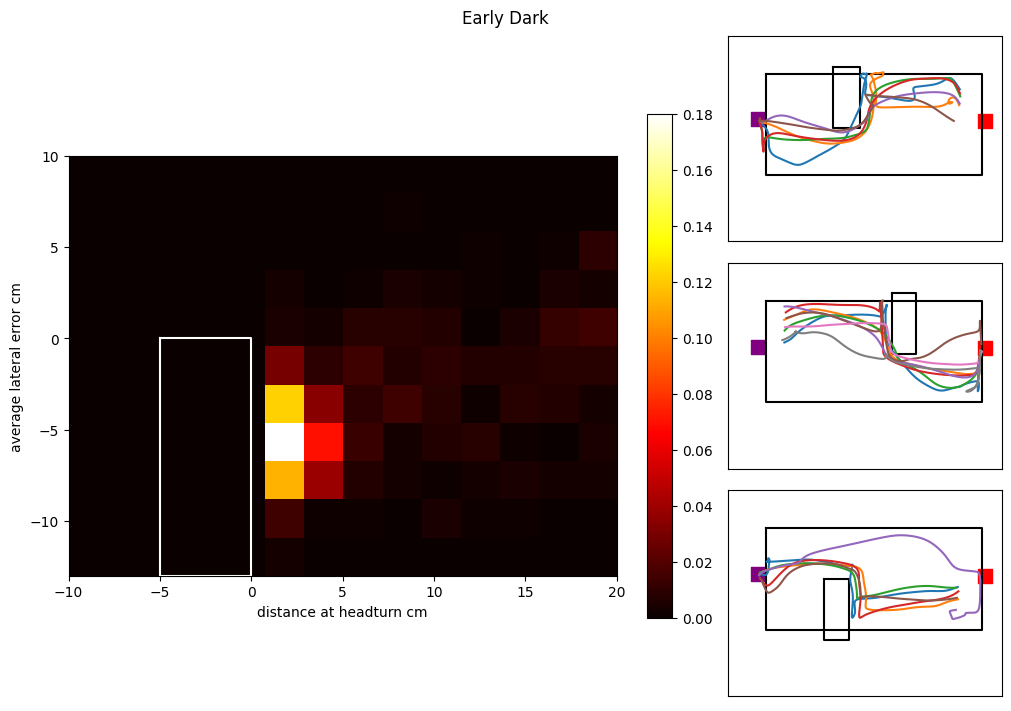

In [246]:

fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Early Dark')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long,short])
data = data[(data.date_index == 0)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J704RT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J704RT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J704RT') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)


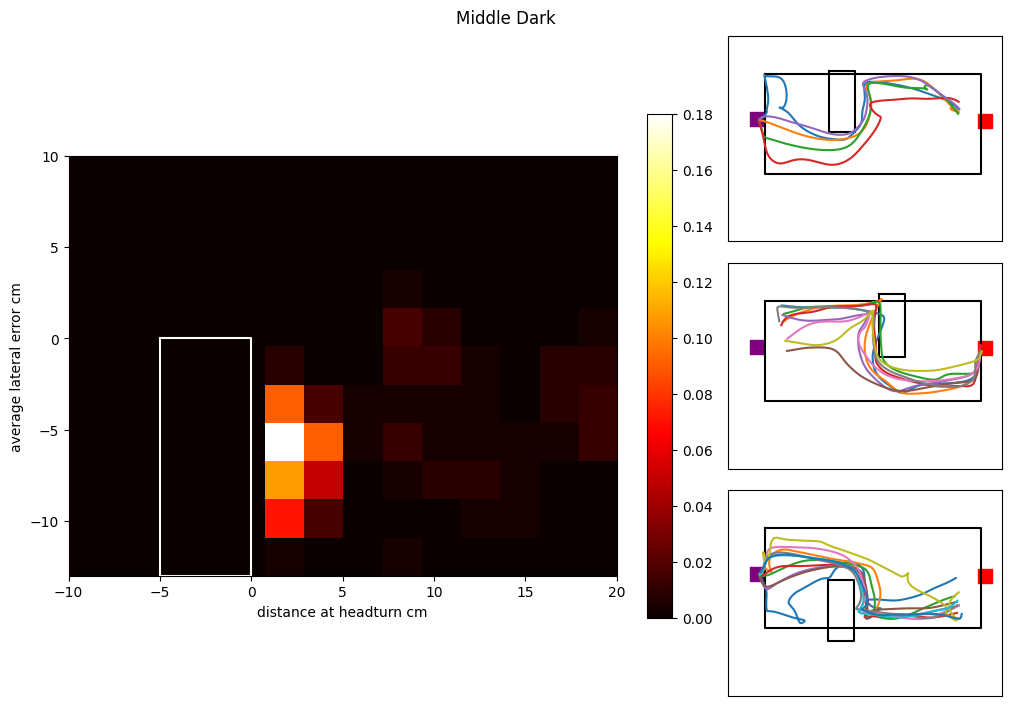

In [247]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Middle Dark')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long,short])
data = data[(data.date_index == 3)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J704LN') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J704LN') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J704LN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

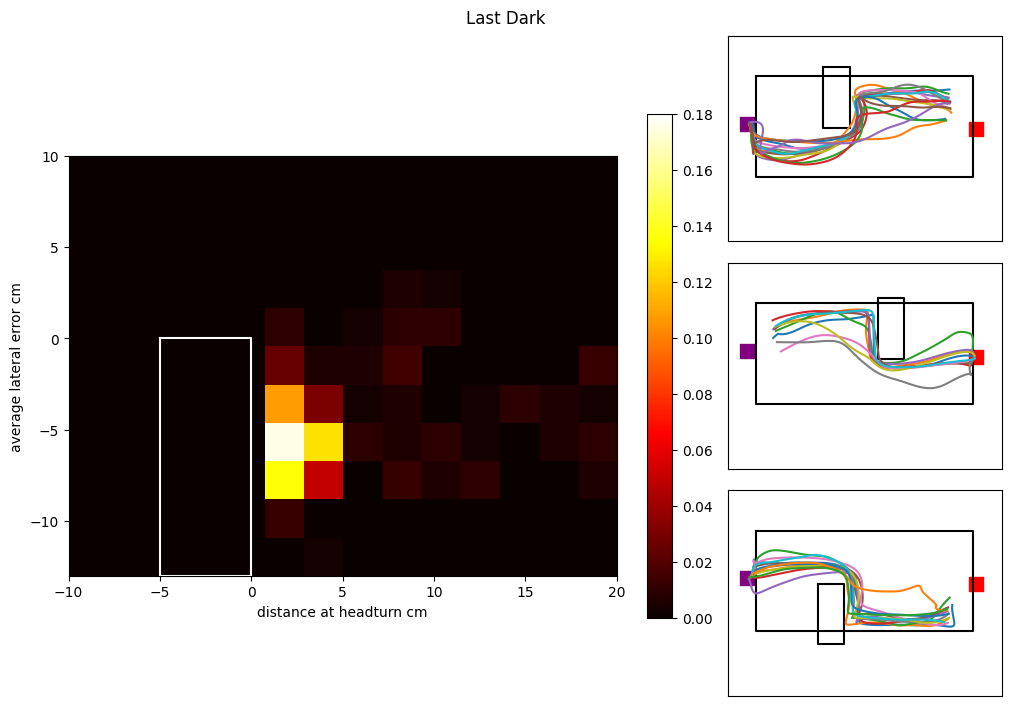

In [256]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Last Dark')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long,short])
data = data[(data.date_index == 5)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

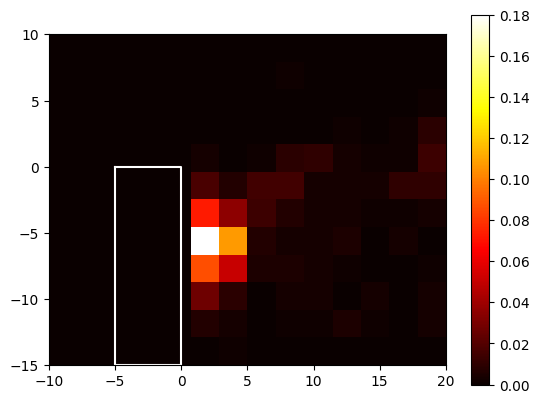

In [185]:
data = pd.concat([long,short])
data = data[(data.date_index == 1)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

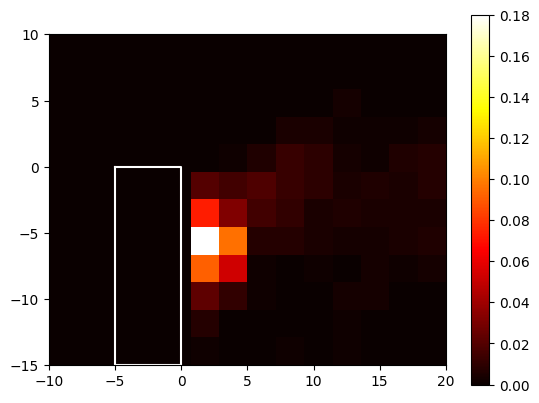

In [88]:
data = data = pd.concat([long,short])
data = data[(data.date_index == 2)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

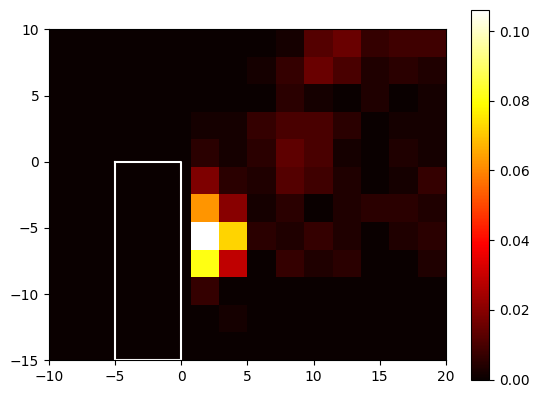

In [78]:
data =J704_oa_df
data = data[(data.date_index == 5)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

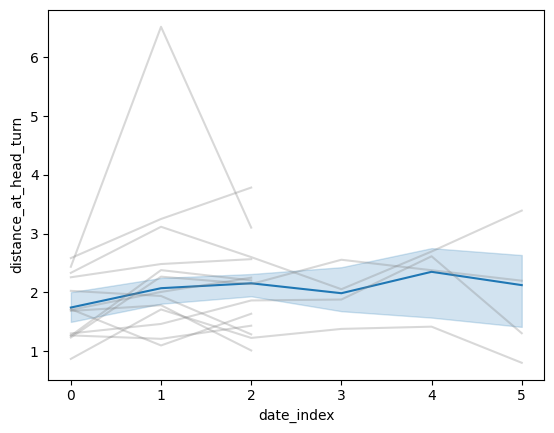

In [86]:
palette = sns.color_palette(['grey'], len(dark['animal'].unique()))
data = pd.concat([long,short])
sns.lineplot(data = data[(data.avg_lateral_error<=0)&(data.distance_at_head_turn >= 0) ],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=data[(data.avg_lateral_error<=0)&(data.distance_at_head_turn >= 0) ],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='avg_lateral_error'>

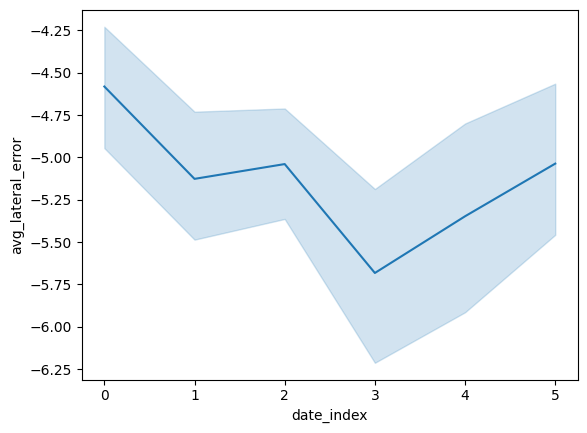

In [87]:
sns.lineplot(data = long[(long.distance_at_head_turn >= 0) ],x ='date_index',y ='avg_lateral_error')

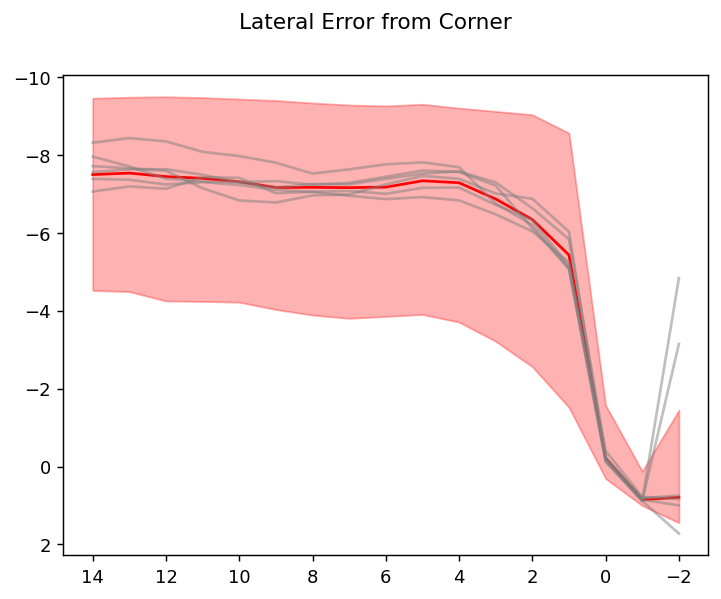

In [102]:

xnew =  np.arange(-2, 15, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = pd.concat([long,short])
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)

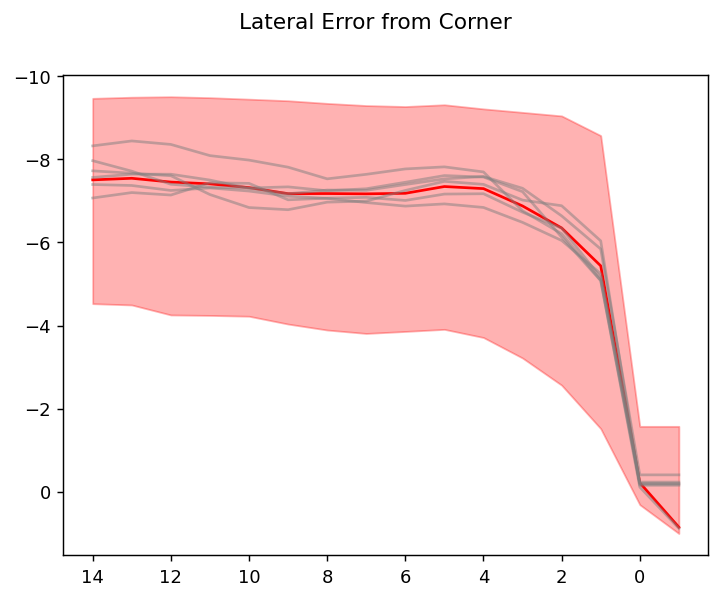

In [136]:

xnew =  np.arange(-1, 15, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
df = pd.concat([long,short])
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)

ax.fill_between(xnew, edge_outliers(q1,1), edge_outliers(q3,1), color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)

In [133]:
np.diff(q1)

array([-0.0272581 , -0.01183347,  0.02245372,  0.03611293,  0.03782906,
        0.0639356 ,  0.05187333,  0.02386331, -0.04288397,  0.0991578 ,
        0.08410536,  0.08490535,  0.47352742,  0.        ])

In [130]:
edge_outliers(q1,0)

array([-9.46642077, -9.49367887, -9.50551234, -9.48305862, -9.44694569,
       -9.40911663, -9.34518103, -9.2933077 , -9.26944439, -9.31232836,
       -9.21317055, -9.12906519, -9.04415984, -8.57063243, -1.57514991,
       -1.57514991])

In [128]:
q3

array([-4.52715367, -4.49542567, -4.2553812 , -4.24388436, -4.22429096,
       -4.03605969, -3.89261649, -3.81003243, -3.8585035 , -3.90874676,
       -3.71230004, -3.21846604, -2.56571896, -1.5203497 ,  0.30949411,
        1.00324761])

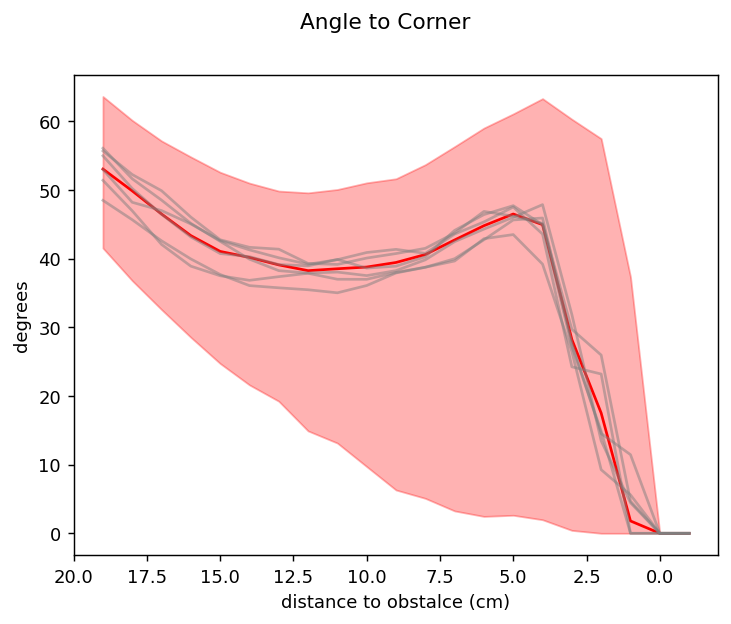

In [122]:
df = long
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-1, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
#ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,2.5)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)

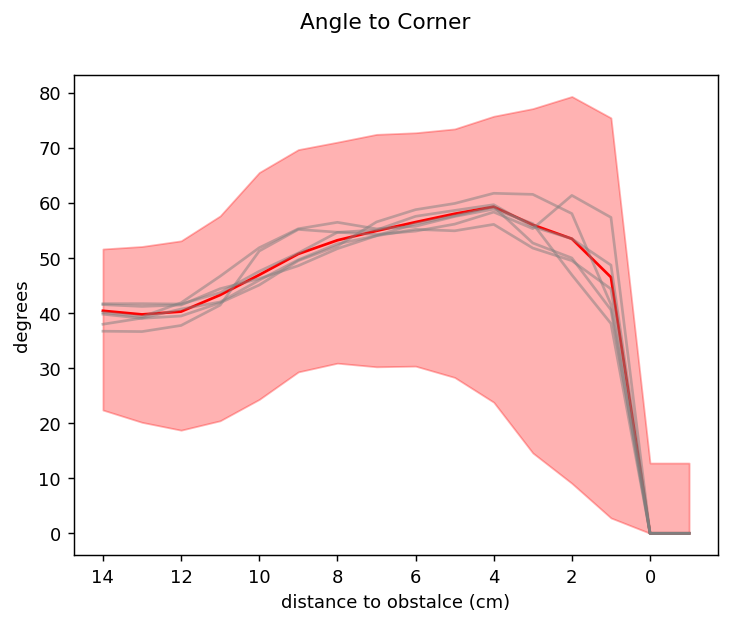

In [123]:
df = pd.concat([long,short])
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-1, 15, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
#ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1.5)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)

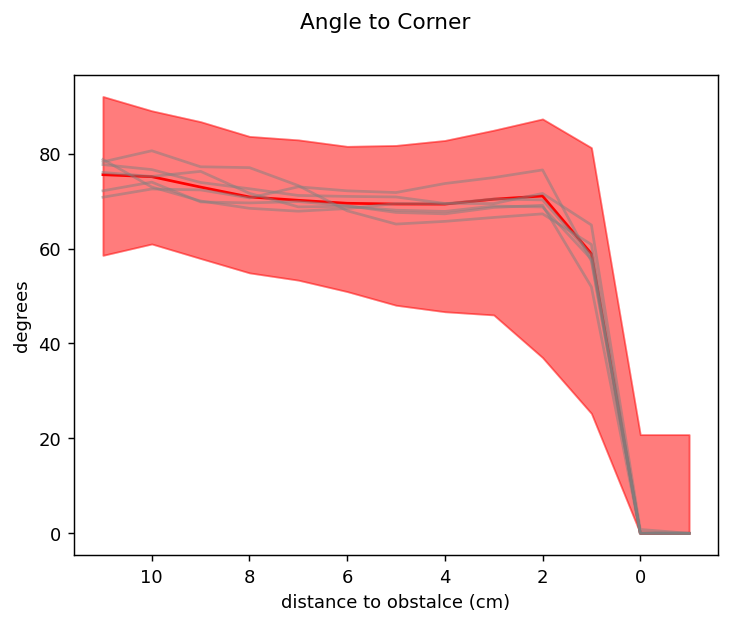

In [119]:
df = short
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-1, 12, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)

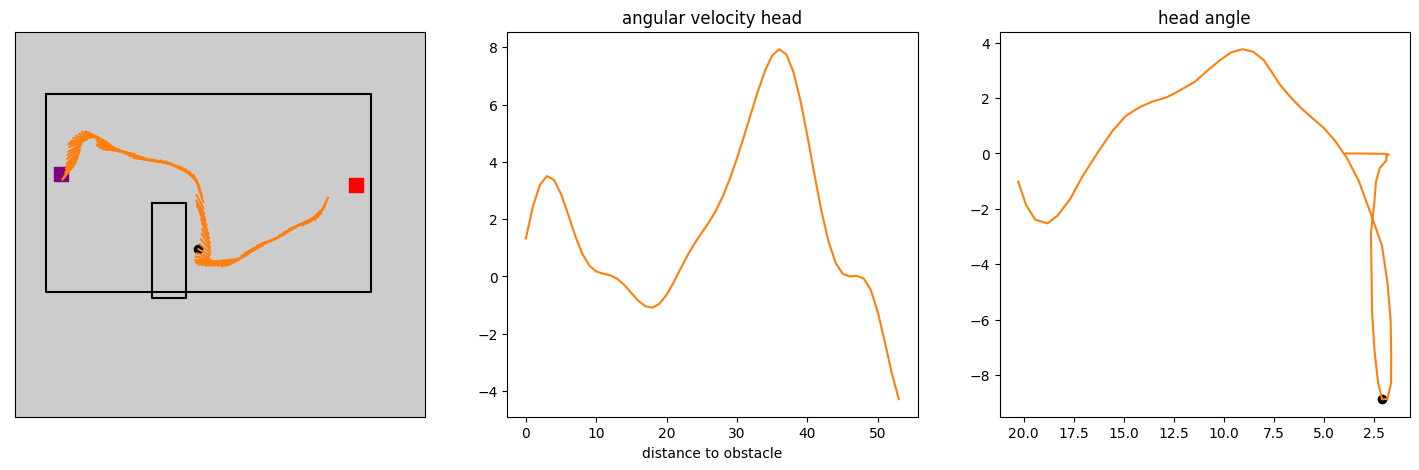

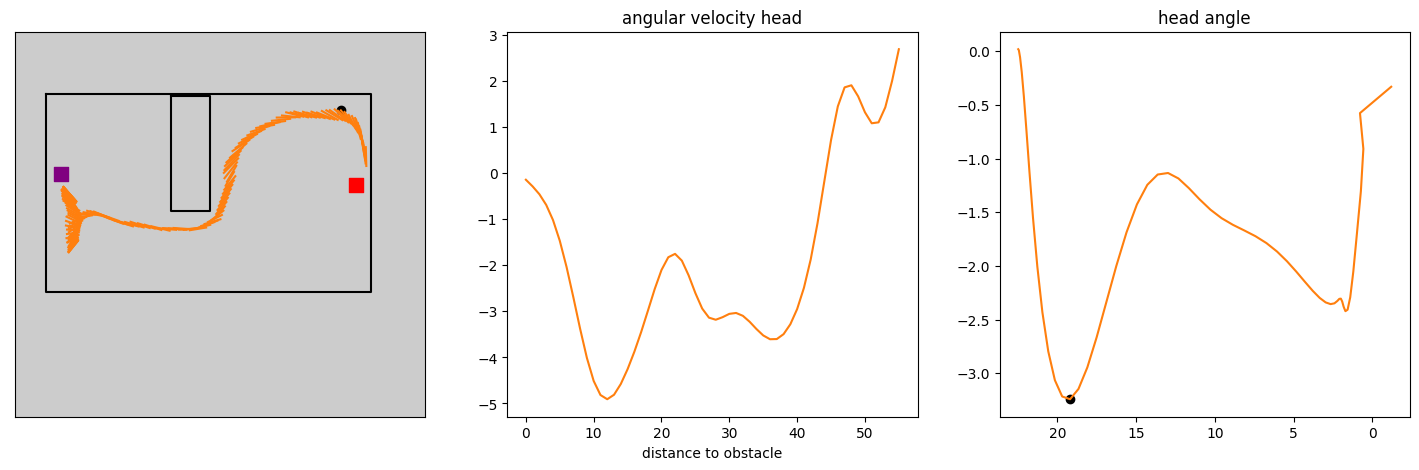

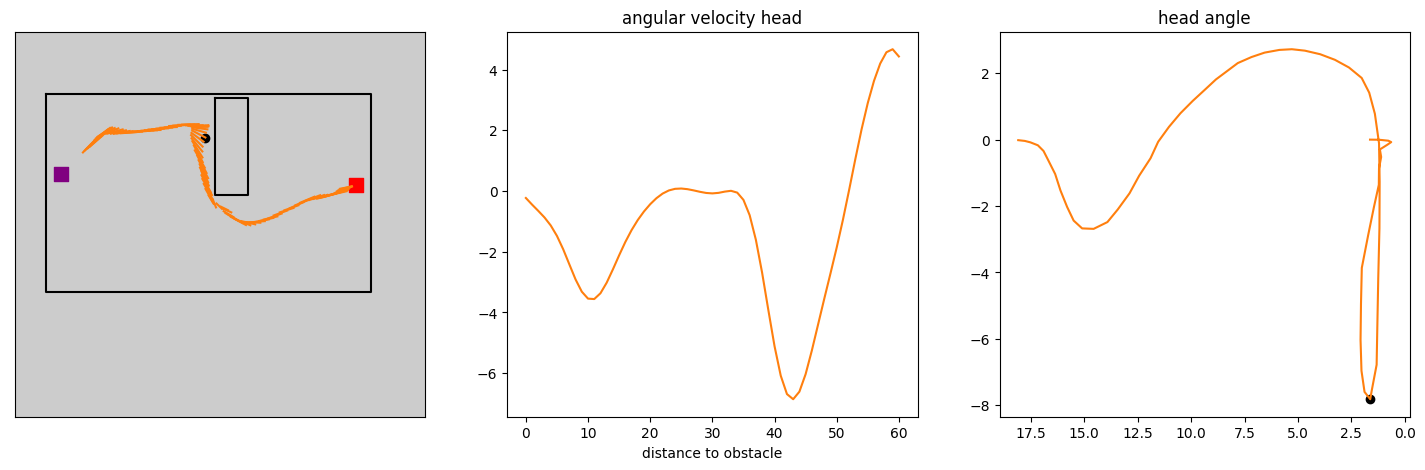

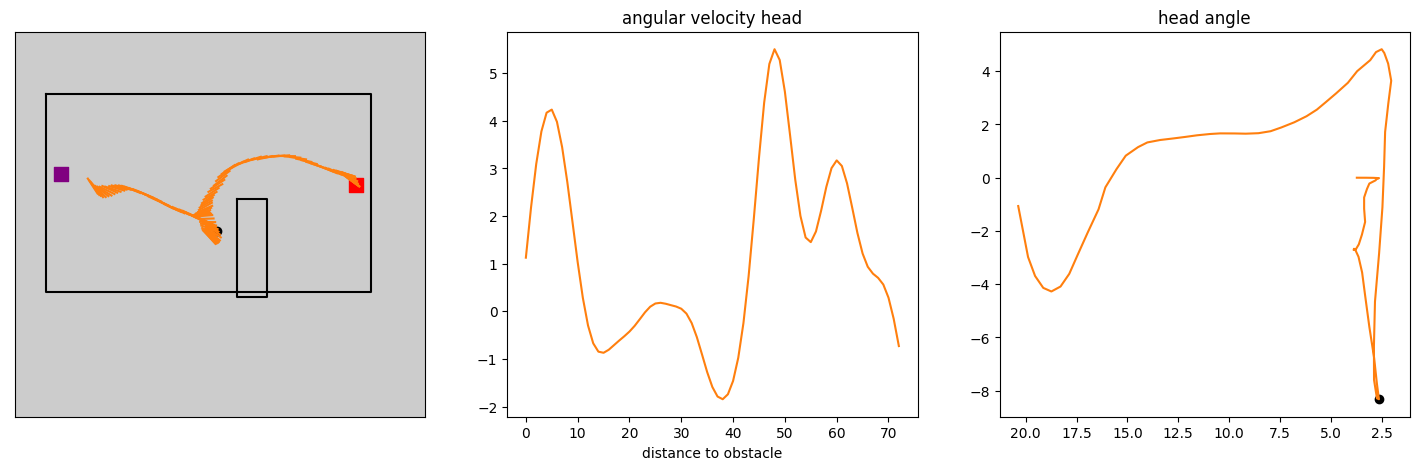

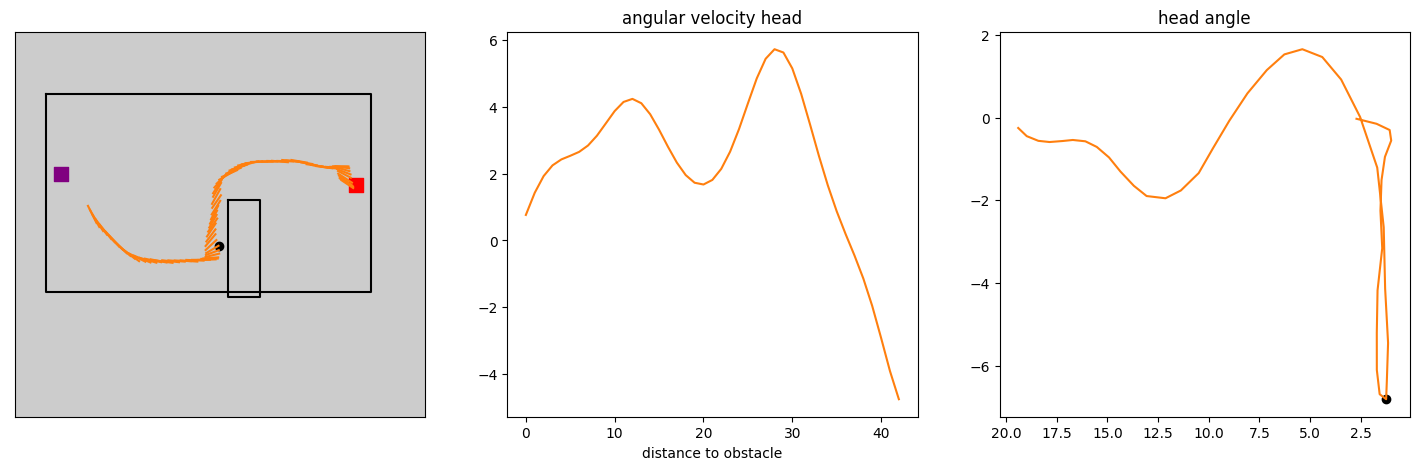

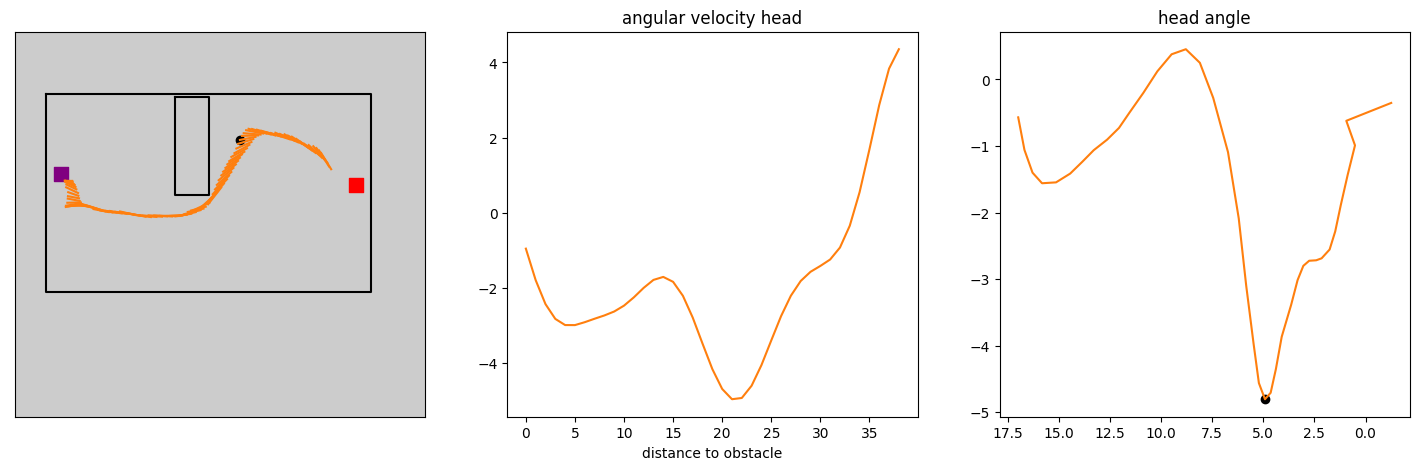

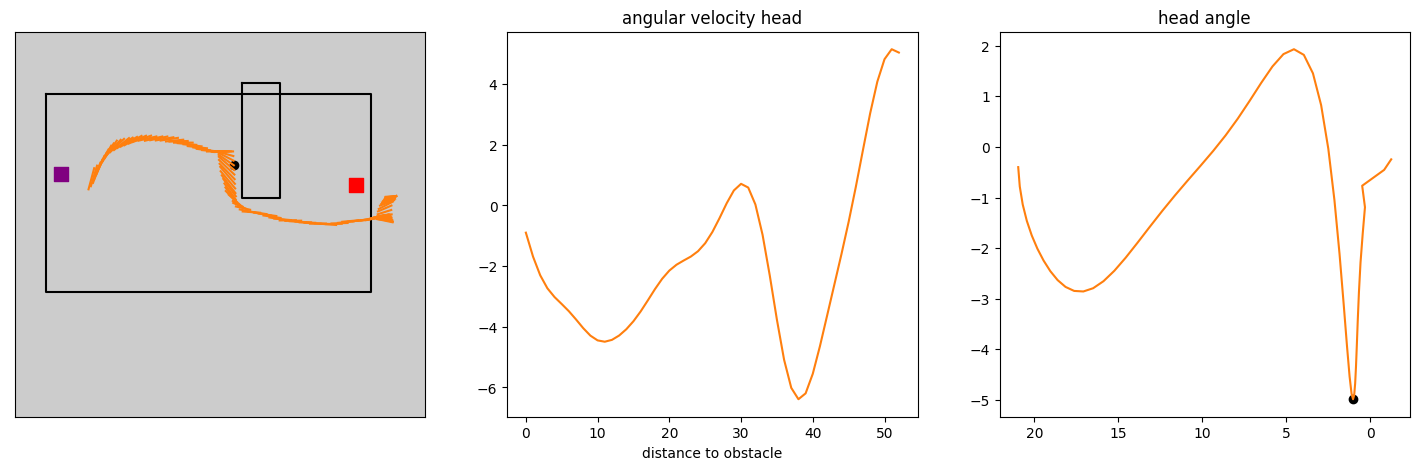

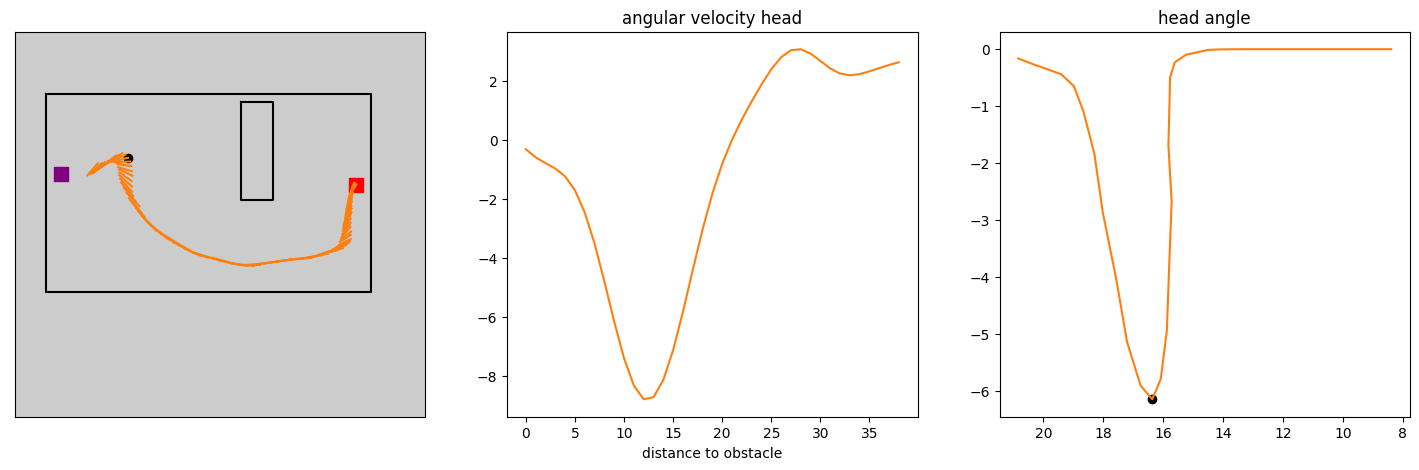

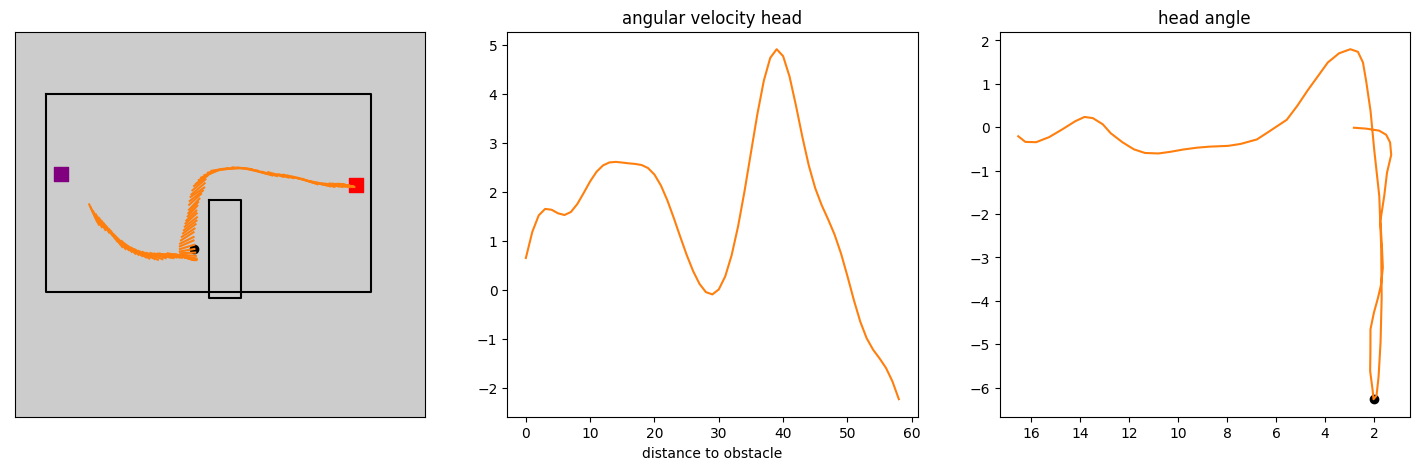

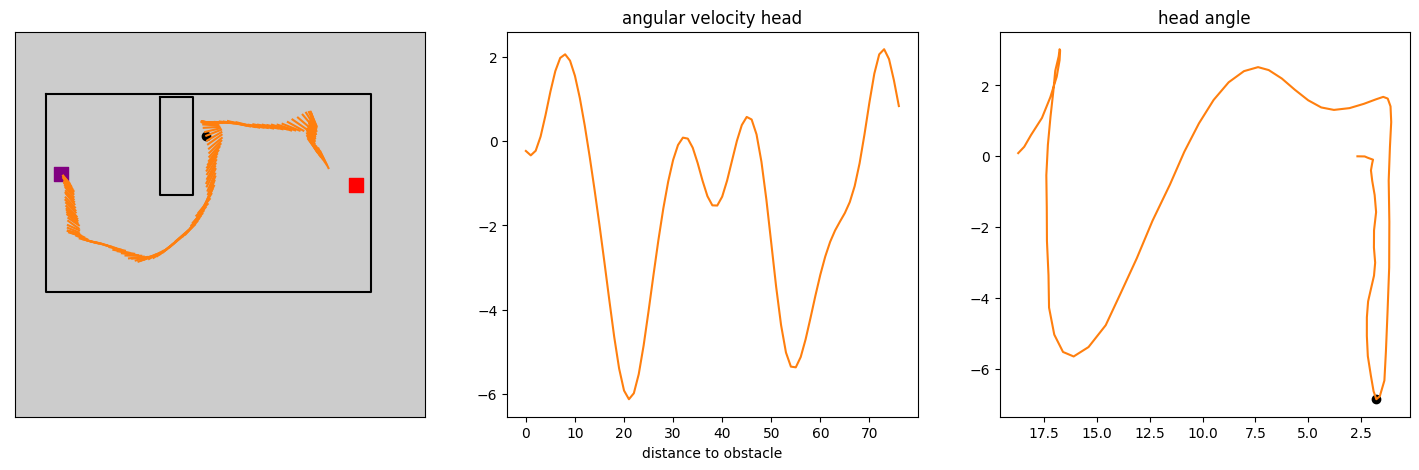

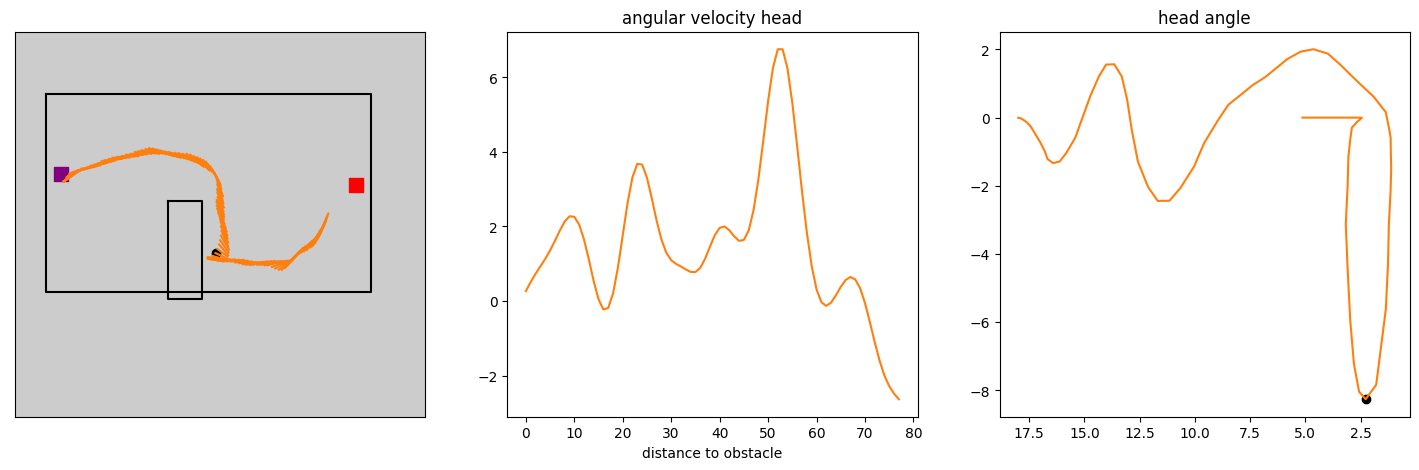

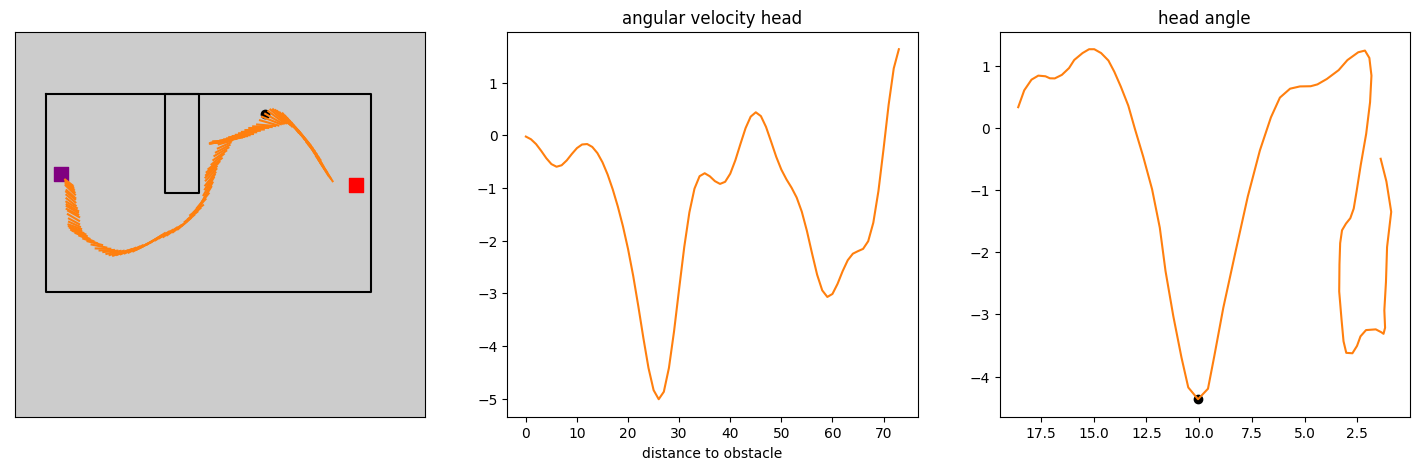

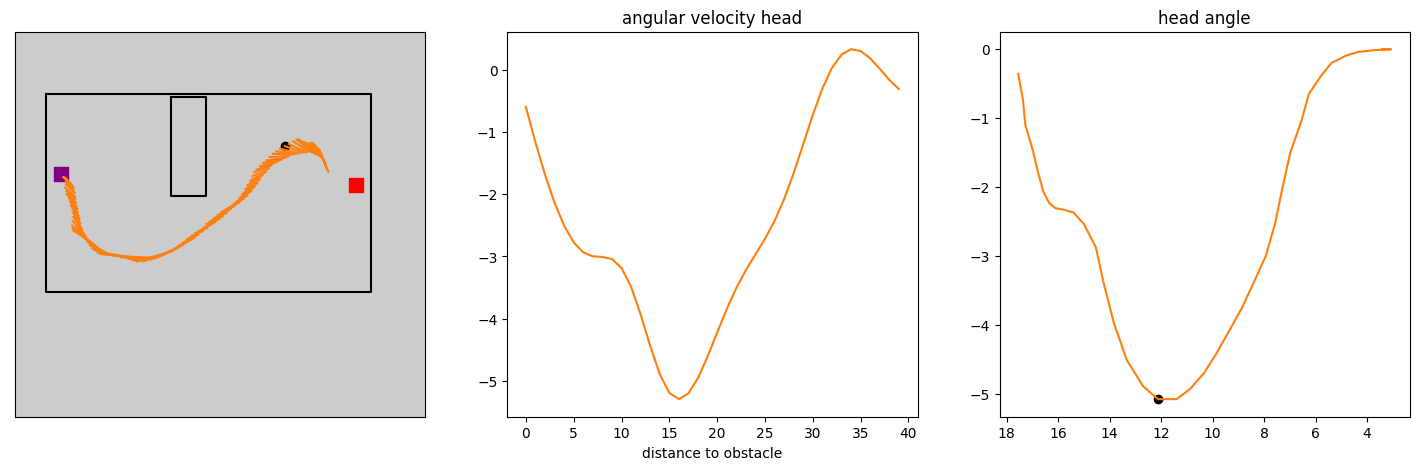

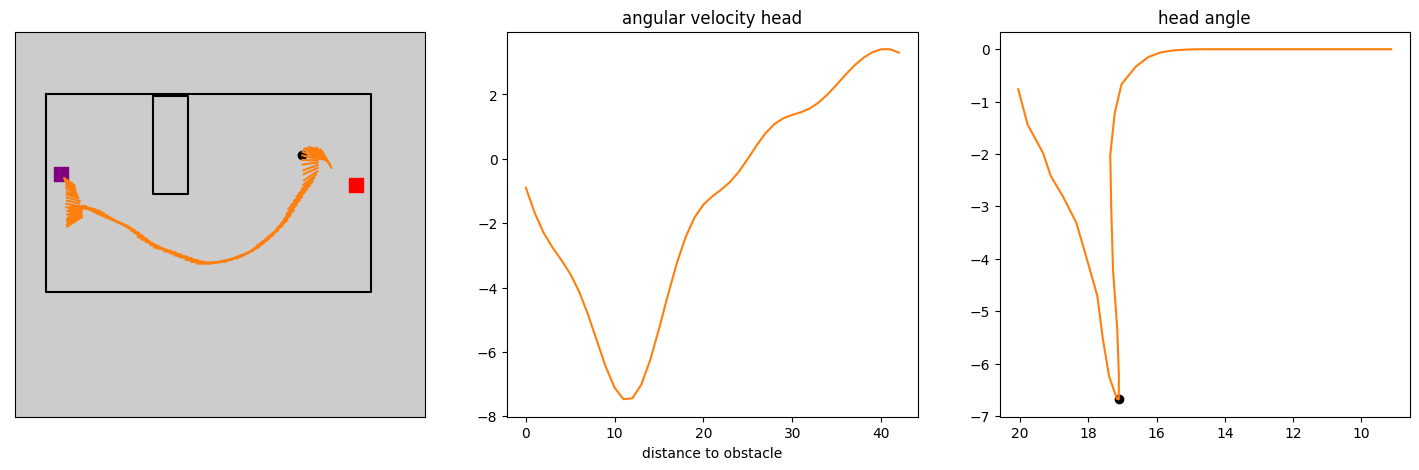

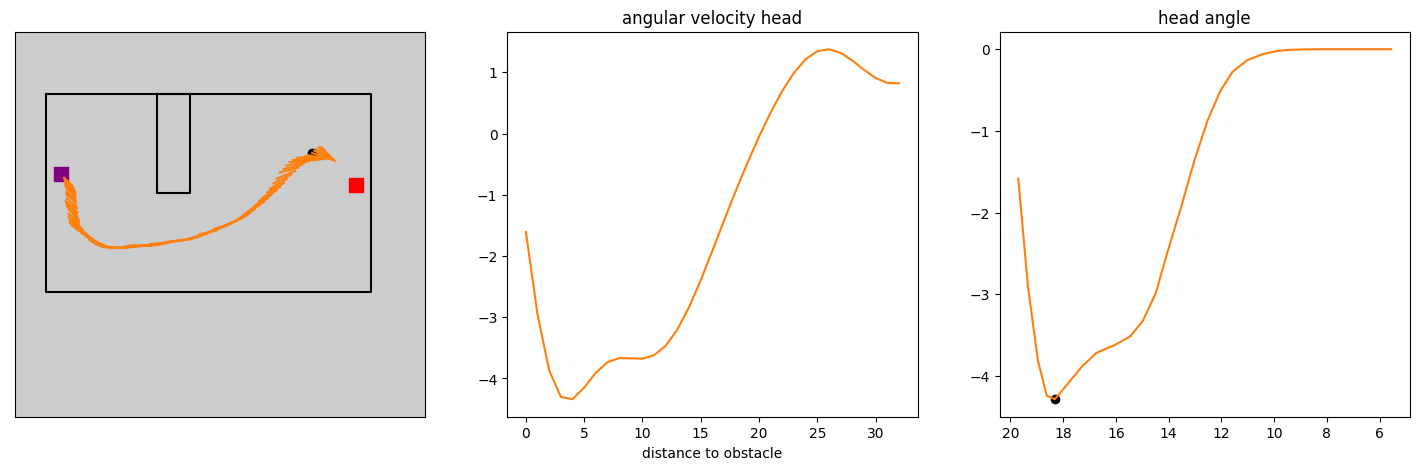

In [269]:
test = long[long.date_index == 0.0].sample(15)
for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[2].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title('angular velocity head')
    ax[2].set_title('head angle')
   
    #ax[1].set_ylim(-12,2)
    ax[1].set_xlabel('distance to obstacle')
    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[2].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_corner_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')

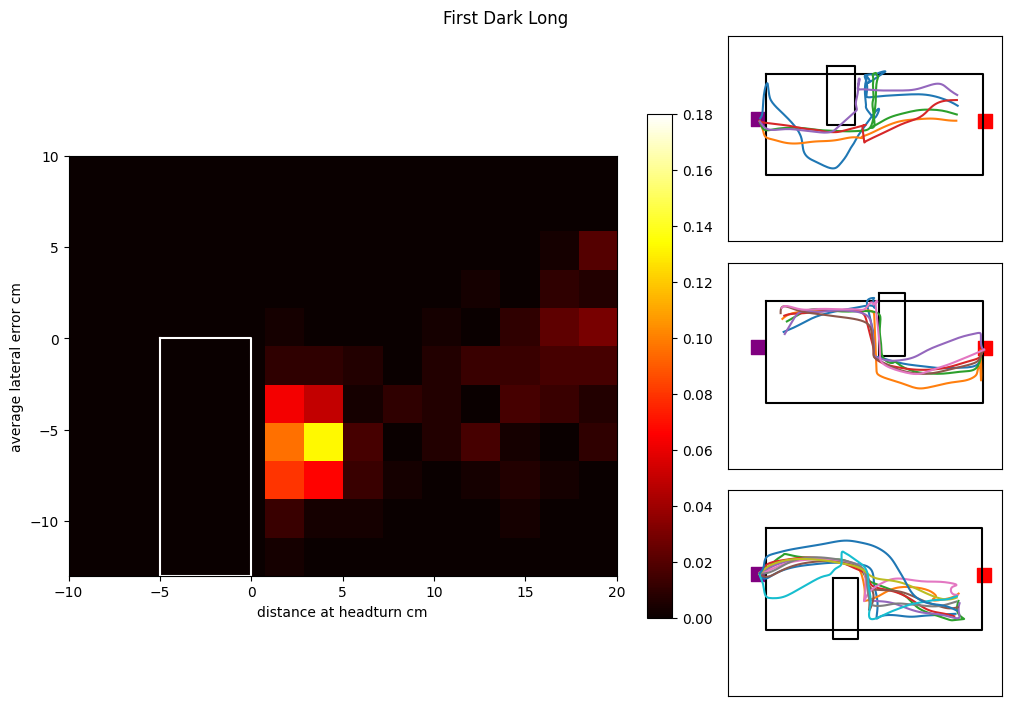

In [271]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('First Dark Long')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long])
data = data[(data.date_index == 0)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J704NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

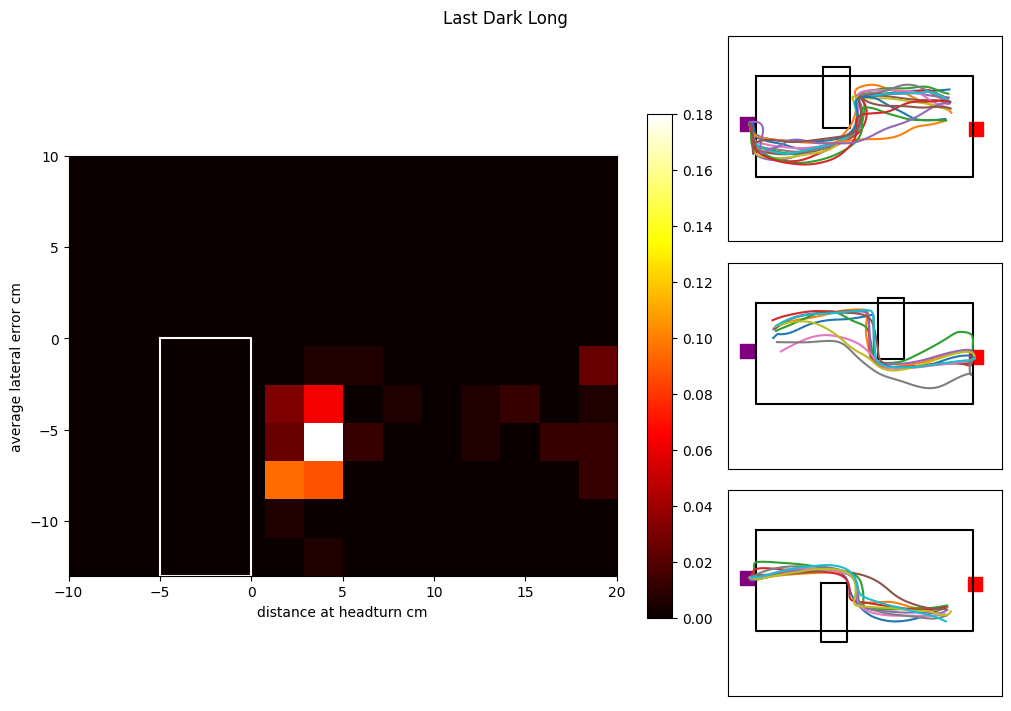

In [272]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Last Dark Long')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long])
data = data[(data.date_index == 5)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J704NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

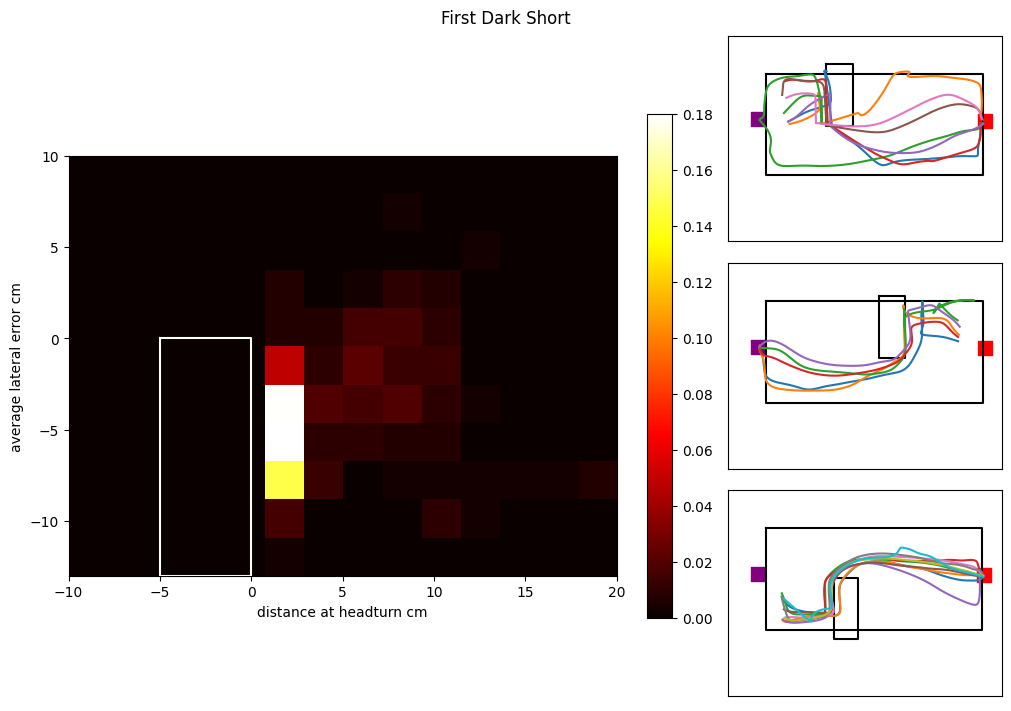

In [274]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('First Dark Short')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([short])
data = data[(data.date_index == 0)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 0)&(data.odd == 'left')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 1)&(data.odd == 'right')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J704NN') &(data.obstacle_cluster == 4)&(data.odd == 'left')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

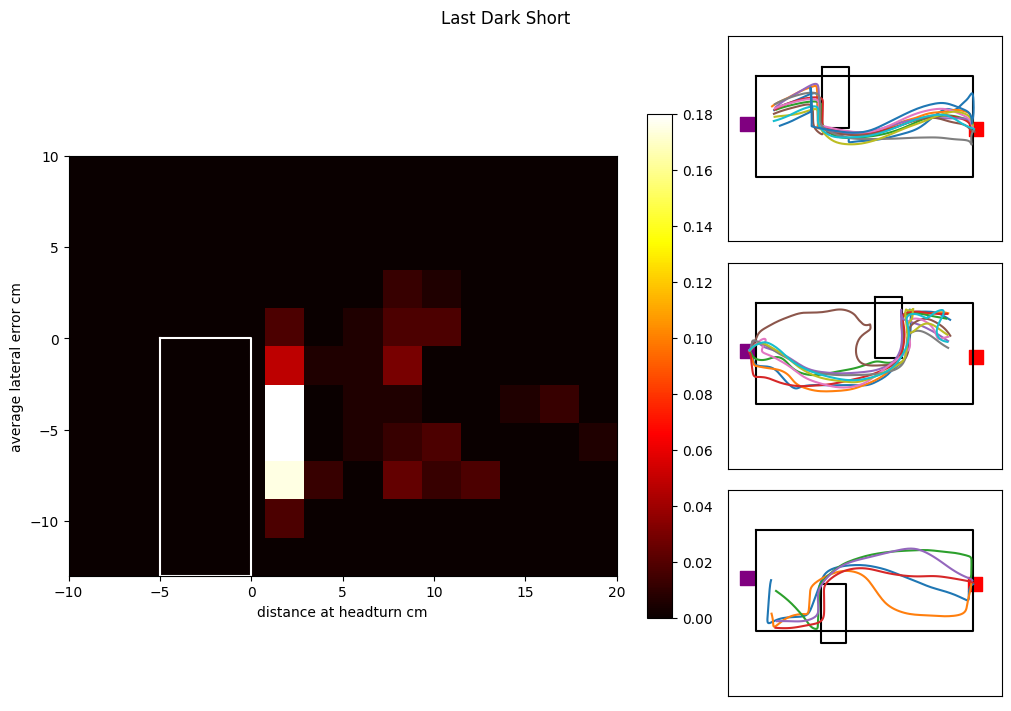

In [275]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Last Dark Short')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([short])
data = data[(data.date_index == 5)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 0)&(data.odd == 'left')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J704LT') &(data.obstacle_cluster == 1)&(data.odd == 'right')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J704NN') &(data.obstacle_cluster == 4)&(data.odd == 'left')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)